##  Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

df = pd.read_csv('/Users/shraddhaingle/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

os.makedirs('/Users/shraddhaingle/Downloads/charts', exist_ok=True)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(f"✅ Ready — {len(df):,} rows loaded")

✅ Ready — 7,043 rows loaded


## Chart 1: Churn by Contract Type

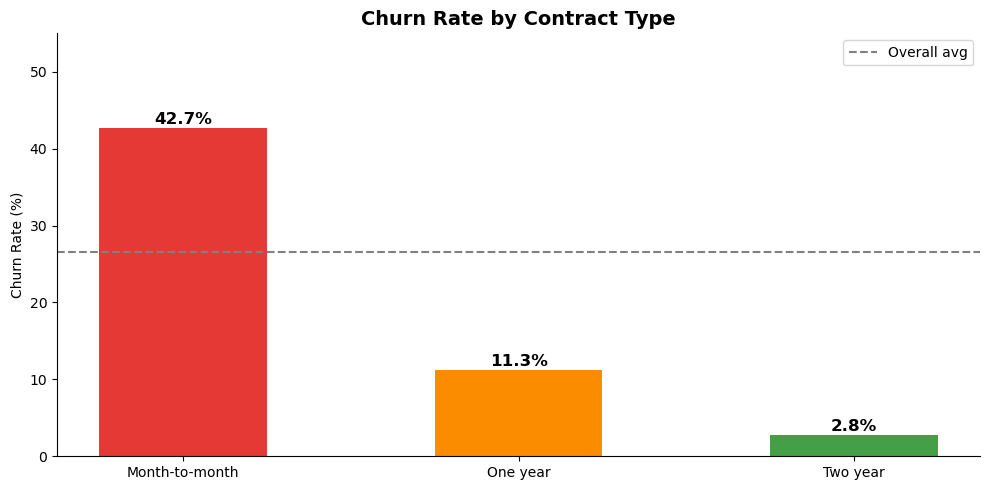

In [2]:
order = ['Month-to-month', 'One year', 'Two year']
churn_rate = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reindex(order)

fig, ax = plt.subplots()
bars = ax.bar(order, churn_rate.values,
              color=['#E53935', '#FB8C00', '#43A047'], width=0.5)

for bar, val in zip(bars, churn_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)
ax.axhline(y=df['Churn'].eq('Yes').mean()*100,
           color='gray', linestyle='--', label='Overall avg')
ax.legend()
plt.tight_layout()
plt.savefig('/Users/shraddhaingle/Downloads/charts/01_contract_churn.png', dpi=150)
plt.show()

## Chart 2: Churn by Tenure

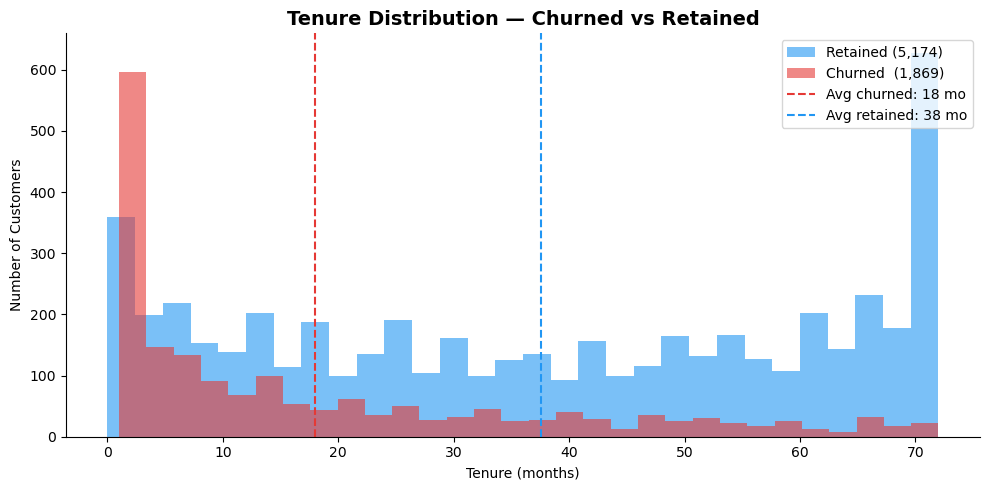

In [3]:
fig, ax = plt.subplots()

churned  = df[df['Churn'] == 'Yes']['tenure']
retained = df[df['Churn'] == 'No']['tenure']

ax.hist(retained, bins=30, alpha=0.6, color='#2196F3', label=f'Retained ({len(retained):,})')
ax.hist(churned,  bins=30, alpha=0.6, color='#E53935', label=f'Churned  ({len(churned):,})')

ax.axvline(churned.mean(),  color='#E53935', linestyle='--',
           label=f'Avg churned: {churned.mean():.0f} mo')
ax.axvline(retained.mean(), color='#2196F3', linestyle='--',
           label=f'Avg retained: {retained.mean():.0f} mo')

ax.set_title('Tenure Distribution — Churned vs Retained', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
plt.savefig('/Users/shraddhaingle/Downloads/charts/02_tenure_churn.png', dpi=150)
plt.show()

## Chart 3: Churn by Internet Service

/var/folders/v1/mgjfv8292kldd2gw4sc4z0vh0000gn/T/ipykernel_96425/1529705937.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Fiber optic', 'DSL', 'No internet'])


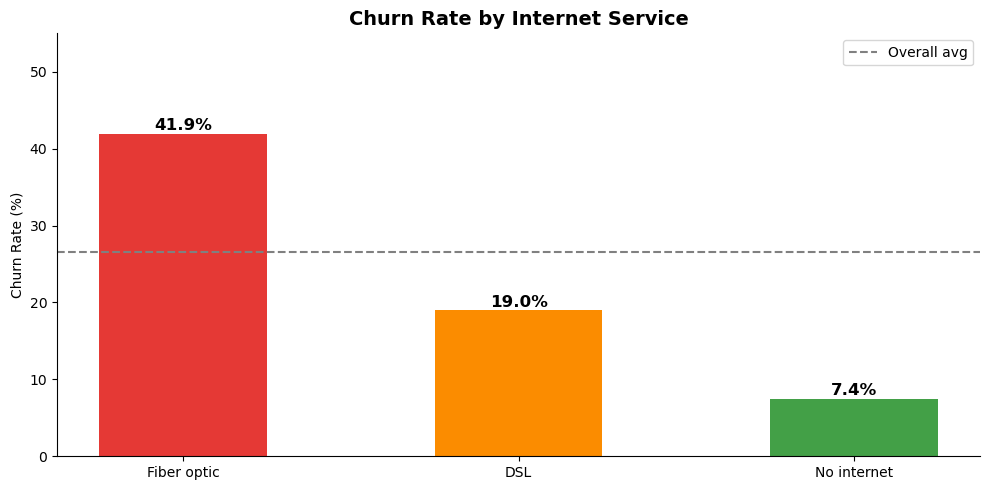

In [4]:
order = ['Fiber optic', 'DSL', 'No']
churn_rate = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reindex(order)

fig, ax = plt.subplots()
bars = ax.bar(order, churn_rate.values,
              color=['#E53935', '#FB8C00', '#43A047'], width=0.5)

for bar, val in zip(bars, churn_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

ax.set_title('Churn Rate by Internet Service', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)
ax.set_xticklabels(['Fiber optic', 'DSL', 'No internet'])
ax.axhline(y=df['Churn'].eq('Yes').mean()*100,
           color='gray', linestyle='--', label='Overall avg')
ax.legend()
plt.tight_layout()
plt.savefig('/Users/shraddhaingle/Downloads/charts/03_internet_churn.png', dpi=150)
plt.show()

## Chart 4: Heatmap 

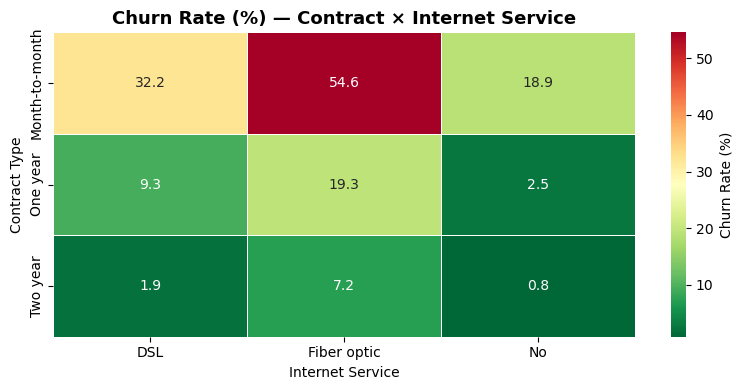

In [5]:
pivot = df.pivot_table(
    values='Churn',
    index='Contract',
    columns='InternetService',
    aggfunc=lambda x: round((x == 'Yes').mean() * 100, 1)
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.1f',
            cmap='RdYlGn_r', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Churn Rate (%)'})

ax.set_title('Churn Rate (%) — Contract × Internet Service',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Internet Service')
ax.set_ylabel('Contract Type')
plt.tight_layout()
plt.savefig('/Users/shraddhaingle/Downloads/charts/04_heatmap.png', dpi=150)
plt.show()

## Chart 5: Monthly Charges Distribution

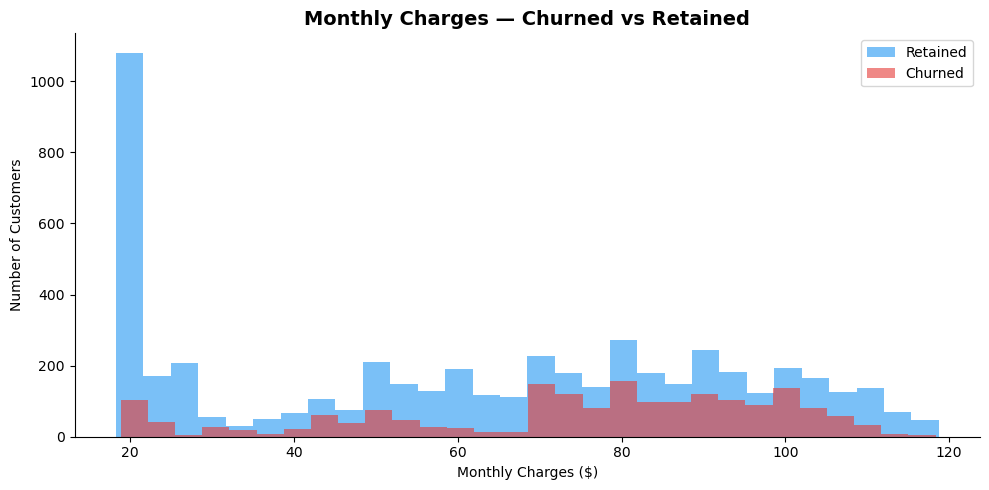

Avg charge — Churned  : $74.44
Avg charge — Retained : $61.27


In [6]:
fig, ax = plt.subplots()

ax.hist(df[df['Churn']=='No']['MonthlyCharges'],
        bins=30, alpha=0.6, color='#2196F3', label='Retained')
ax.hist(df[df['Churn']=='Yes']['MonthlyCharges'],
        bins=30, alpha=0.6, color='#E53935', label='Churned')

ax.set_title('Monthly Charges — Churned vs Retained', fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
plt.savefig('/Users/shraddhaingle/Downloads/charts/05_monthly_charges.png', dpi=150)
plt.show()

print(f"Avg charge — Churned  : ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")
print(f"Avg charge — Retained : ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")

## Chart 6: Senior Citizen Churn

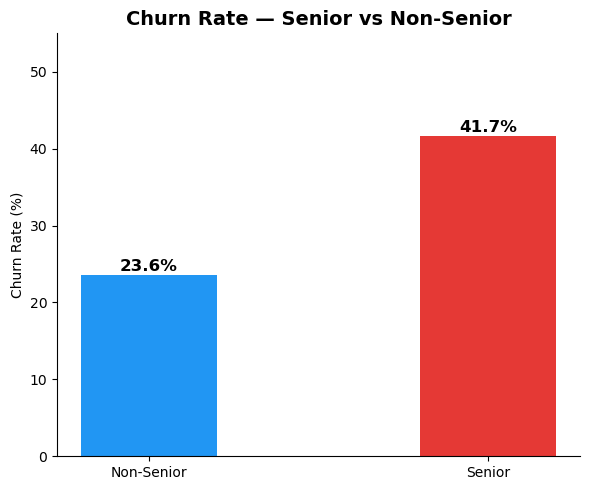

In [7]:
senior_churn = df.groupby('SeniorCitizen')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['Non-Senior', 'Senior'],
              senior_churn.reindex(['No', 'Yes']).values,
              color=['#2196F3', '#E53935'], width=0.4)

for bar, val in zip(bars, senior_churn.reindex(['No','Yes']).values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

ax.set_title('Churn Rate — Senior vs Non-Senior', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)
plt.tight_layout()
plt.savefig('/Users/shraddhaingle/Downloads/charts/06_senior_churn.png', dpi=150)
plt.show()